# Perceptron for Classifying Digit 8 (Handwritten Digits)

**Challenge:** Train a perceptron to classify the number 8 in the handwritten digits dataset.

Data source: [OpenML dataset 554](https://www.openml.org/d/554) (MNIST 784).

We follow these steps:
1. Implement a perceptron that takes 784 pixel inputs
2. Prepare the digit dataset with binary labels (8 vs not 8)
3. Implement the training function
4. Experiment with weight and bias initialization
5. Experiment with learning rates
6. Analyze misclassified cases and visualize the weight distribution in 2D

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## (1) Perceptron with 784 inputs

A generic perceptron: output = 1 if **w·x + b > 0**, else 0.  
For digit images we use 784 pixel values as the input vector **x** (28×28 flattened).

In [2]:
def perceptron(signals, weights, bias):
    """Generic perceptron: activated (True/1) if weighted sum + bias > 0.
    
    Parameters
    ----------
    signals : array-like, shape (n_features,) e.g. (784,) for flattened digit
    weights : array-like, same shape as signals
    bias : float
    
    Returns
    -------
    activated : bool
    """
    signals = np.asarray(signals, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weighted_sum = np.dot(signals, weights) + bias
    return weighted_sum > 0

## (2) Prepare digit data: binary classification (8 vs not 8)

Load OpenML 554 (MNIST 784). Convert labels to binary: 1 for digit 8, 0 otherwise.  
Convert 2D images to 1D vectors (784 pixels). Optionally scale features and split into train/test.

In [3]:
# Load OpenML dataset 554 (MNIST 784)
mnist = fetch_openml(data_id=554, as_frame=False, parser="auto")
X_full = mnist.data   # (n_samples, 784) already flattened
y_digit = np.array(mnist.target, dtype=int)  # digits 0..9

# Binary labels: 1 = digit 8, 0 = not 8
y_binary = (y_digit == 8).astype(int)

# Optional: use a subset for faster training (full set is 70k samples)
max_samples = 15000
if len(X_full) > max_samples:
    rng = np.random.RandomState(42)
    idx = rng.permutation(len(X_full))[:max_samples]
    X_full, y_digit, y_binary = X_full[idx], y_digit[idx], y_binary[idx]

# Train/test split (keep digit labels for later analysis of misclassifications)
idx = np.arange(len(X_full))
i_train, i_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y_binary
)
X_train, X_test = X_full[i_train], X_full[i_test]
y_train, y_test = y_binary[i_train], y_binary[i_test]
y_digit_train, y_digit_test = y_digit[i_train], y_digit[i_test]

# Scale to similar range (helps perceptron convergence)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))

n_features = X_train.shape[1]
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}, Features: {n_features}")
print(f"Fraction of 8's in train: {y_train.mean():.3f}")

Train size: 12000, Test size: 3000, Features: 784
Fraction of 8's in train: 0.097


## (3) Train perceptron function

Update rule:  
**w** ← **w** + η (y_true − y_pred) **x**  
**b** ← **b** + η (y_true − y_pred)  

We track misclassifications per epoch.

In [4]:
def train_perceptron(X, y, weights, bias, epochs, learning_rate, shuffle=True, random_state=None):
    """Train perceptron with the standard update rule.
    
    Shuffling each epoch (default) makes the learning rate have a visible effect;
    without it, the same sample order can make different learning rates look similar.
    
    Returns
    -------
    weights, bias, misclassifications (array of length epochs+1)
    """
    weights = np.asarray(weights, dtype=float).copy() # Fill in by students?
    bias = float(bias)
    eta = float(learning_rate)  # ensure float so updates are not truncated
    misclassifications = np.zeros(epochs + 1)
    rng = np.random.RandomState(random_state)
    n_samples = len(y)
    
    misclassifications[0] = np.sum([yi != perceptron(xi, weights, bias) for xi, yi in zip(X, y)])
    
    for epoch in range(epochs):
        order = rng.permutation(n_samples) if shuffle else np.arange(n_samples)
        for i in order:
            xi, yi = X[i], y[i]
            pred = perceptron(xi, weights, bias)
            err = (yi - (1 if pred else 0))
            weights += eta * err * np.asarray(xi, dtype=float)
            bias += eta * err
        misclassifications[epoch + 1] = np.sum([yi != perceptron(xi, weights, bias) for xi, yi in zip(X, y)])
    
    return weights, bias, misclassifications

## (4) Test different weight and bias initializations

Try: zeros, small random, and scaled random. Use a fixed learning rate and epochs for comparison.

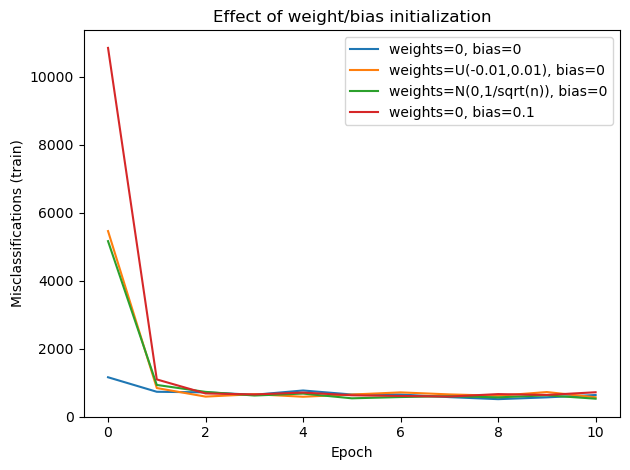

Final train misclassifications: 636.0 569.0 528.0 717.0


In [5]:
epochs, lr = 10, 0.001
n = n_features

# Scheme A: all zeros # Fill in by students?
w0_a = np.zeros(n)
b0_a = 0.0
w_a, b_a, misc_a = train_perceptron(X_train, y_train, w0_a, b0_a, epochs, lr)

# Scheme B: small random uniform [-0.01, 0.01]
rng = np.random.RandomState(0)
w0_b = rng.uniform(-0.01, 0.01, size=n)
b0_b = 0.0
w_b, b_b, misc_b = train_perceptron(X_train, y_train, w0_b, b0_b, epochs, lr)

# Scheme C: scaled random (e.g. 1/sqrt(n))
w0_c = rng.randn(n) / np.sqrt(n)
b0_c = 0.0
w_c, b_c, misc_c = train_perceptron(X_train, y_train, w0_c, b0_c, epochs, lr)

# Scheme D: zeros for weights, small positive bias (e.g. 0.1)
w0_d = np.zeros(n)
b0_d = 0.1
w_d, b_d, misc_d = train_perceptron(X_train, y_train, w0_d, b0_d, epochs, lr)

fig, ax = plt.subplots()
ax.plot(misc_a, label="weights=0, bias=0")
ax.plot(misc_b, label="weights=U(-0.01,0.01), bias=0")
ax.plot(misc_c, label="weights=N(0,1/sqrt(n)), bias=0")
ax.plot(misc_d, label="weights=0, bias=0.1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassifications (train)")
ax.legend()
ax.set_title("Effect of weight/bias initialization")
plt.tight_layout()
plt.show()
print("Final train misclassifications:", misc_a[-1], misc_b[-1], misc_c[-1], misc_d[-1])

## (5) Test different learning rates

Fix initialization (e.g. zeros) and vary η to see convergence speed and stability.

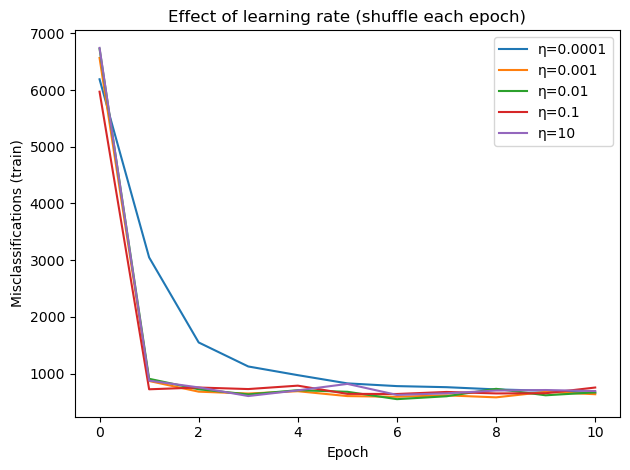

In [7]:
epochs = 10 
learning_rates = [0.0001, 0.001, 0.01, 0.1 ,10]# Fill in by students?
# learning_rates = [0.0001, 1000]

fig, ax = plt.subplots()
for lr in learning_rates:
    w, b, misc = train_perceptron(X_train, y_train, rng.uniform(-0.1, 0.1, size=n), 0.1, epochs, lr, shuffle=True, random_state=42)
    ax.plot(misc, label=f"η={lr}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassifications (train)")
ax.legend()
ax.set_title("Effect of learning rate (shuffle each epoch)")
plt.tight_layout()
plt.show()

## Train a good perceptron (chosen init and learning rate)

We use zeros init and a moderate learning rate, enough epochs to converge.

Train accuracy: 0.9489, Test accuracy: 0.9297
Final train misclassifications: 613 / 12000


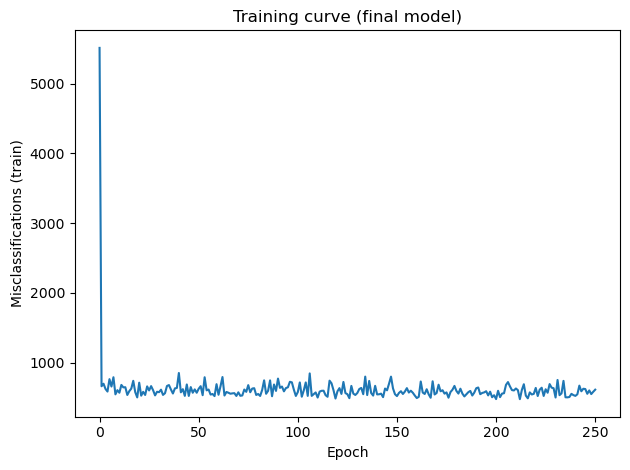

In [ ]:
# Train final model
epochs_final, lr_final = 250, 0.001 # Fill in by students?
weights_final, bias_final, misc_final = train_perceptron(
    X_train, y_train, rng.uniform(-0.01, 0.01, size=n), 0.0, epochs_final, lr_final
)

# Accuracy on train and test
def accuracy(X, y, w, b):
    preds = np.array([perceptron(xi, w, b) for xi in X])
    return (preds == y).mean()

train_acc = accuracy(X_train, y_train, weights_final, bias_final)
test_acc = accuracy(X_test, y_test, weights_final, bias_final)
print(f"Train accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}")
print(f"Final train misclassifications: {misc_final[-1]:.0f} / {len(y_train)}")
plt.figure()
plt.plot(misc_final)
plt.xlabel("Epoch")
plt.ylabel("Misclassifications (train)")
plt.title("Training curve (final model)")
plt.tight_layout()
plt.show()

## (6a) Misclassified cases: why are they difficult?

Identify test set misclassifications and show a few examples. Digits confused with 8 (e.g. 3, 5, 6, 9) or ambiguous 8s help build intuition.

Test misclassifications: 211 / 3000
True digit counts among misclassified: {np.int64(0): 4, np.int64(1): 5, np.int64(2): 20, np.int64(3): 8, np.int64(4): 9, np.int64(5): 34, np.int64(6): 6, np.int64(7): 2, np.int64(8): 111, np.int64(9): 12}


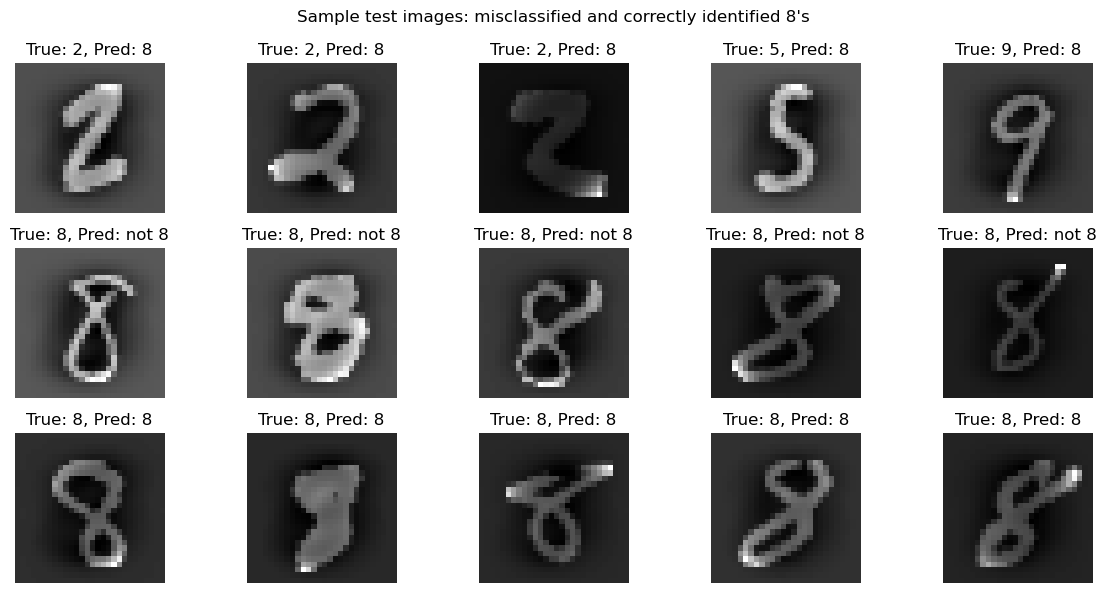

In [ ]:
# Predict on test set 
test_pred = np.array([perceptron(xi, weights_final, bias_final) for xi in X_test])
misclassified = test_pred != y_test
mis_idx = np.where(misclassified)[0]

print(f"Test misclassifications: {misclassified.sum()} / {len(y_test)}")
if len(mis_idx) > 0:
    # Distribution of true digit among misclassified (actual digit label)
    from collections import Counter
    digit_counts = Counter(y_digit_test[mis_idx])
    print("True digit counts among misclassified:", dict(sorted(digit_counts.items())))
    # Show a few examples: false positives (pred 8, not 8) and false negatives (pred not 8, true 8)
    fp = mis_idx[(y_test[mis_idx] == 0) & test_pred[mis_idx]]   # predicted 8, actually not
    fn = mis_idx[(y_test[mis_idx] == 1) & ~test_pred[mis_idx]]  # predicted not 8, actually 8
    correct_8_idx = np.where((y_test == 1) & test_pred)[0]  # correctly identified 8's
    n_show = 5
    fig, axes = plt.subplots(3, n_show, figsize=(12, 6))
    for i, ax_row in enumerate(axes):
        inds = (fp if i == 0 else fn if i == 1 else correct_8_idx)[:n_show]
        for j, k in enumerate(inds):
            img = X_test[k].reshape(28, 28)  # show scaled image; for display could use inverse transform
            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].set_title(f"True: {y_digit_test[k]}, Pred: {'8' if i != 1 else 'not 8'}")
            axes[i, j].axis("off")
    axes[0, 0].set_ylabel("Pred 8, true not 8", fontsize=10)
    axes[1, 0].set_ylabel("Pred not 8, true 8", fontsize=10)
    axes[2, 0].set_ylabel("Correct 8 (true 8, pred 8)", fontsize=10)
    plt.suptitle("Sample test images: misclassified and correctly identified 8's")
    plt.tight_layout()
    plt.show()

## (6b) Weight distribution in 2D (28×28)

Reshape the learned weight vector to 28×28 and visualize. Positive (e.g. red) pixels push toward "8"; negative (e.g. blue) push toward "not 8". We expect high positive weights in regions typical of an 8 (e.g. top and bottom loops). Is that true? (No right answers here, interpreting weights is tricky in general)

In [ ]:
# Reshape weights to 28x28 (same layout as digit images)
W_2d = weights_final.reshape(28, 28)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(W_2d, cmap="RdBu_r", vmin=-np.percentile(np.abs(W_2d), 98), vmax=np.percentile(np.abs(W_2d), 98))
axes[0].set_title("Weights (28×28)\nred=positive (favors 8), blue=negative (favors not 8)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], label="weight")
# Alternative: 0-centered so all positive = red, all negative = blue
max_abs = np.max(np.abs(W_2d))
im1 = axes[1].imshow(W_2d, cmap="RdBu_r", vmin=-max_abs, vmax=max_abs)
axes[1].set_title("Weights (0-centered)\npositive=red, negative=blue")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], label="weight")

axes[2].hist(weights_final.ravel(), bins=50, edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Weight value")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of weights")
plt.tight_layout()
plt.show()
print("Weight stats: min={:.4f}, max={:.4f}, mean={:.4f}".format(weights_final.min(), weights_final.max(), weights_final.mean()))